# Sentiment Analysis on Customer Feedback (NLP)**Amrutha Vinod**### Business ProblemCompanies receive thousands of customer reviews and support messages. Reading them all manually doesn't scale. This project builds a text classifier that automatically labels feedback as **Positive**, **Negative**, or **Neutral**, giving product and support teams fast, scalable visibility into customer sentiment trends.### Approach1. Load customer review text data2. Clean text (lowercase, remove punctuation/noise)3. Convert text to numerical features using **TF-IDF**4. Train and compare two classifiers: Multinomial Naive Bayes (classic text baseline) and Logistic Regression5. Evaluate with macro-averaged Precision, Recall, F1 (important for a 3-class, slightly imbalanced problem)6. Inspect which words most strongly drive each sentiment class*Note: dataset is synthetically generated by composing reviews from phrase banks (subject + opinion + reason), including deliberately ambiguous/mixed-sentiment reviews and ~3% label noise — built to mirror the genuine difficulty of real customer feedback rather than trivially-separable text.*### Why scikit-learn's TF-IDF instead of NLTK?A leaner pipeline with fewer dependencies — `TfidfVectorizer` handles tokenization, stopword removal, and n-grams directly, which is a common, production-friendly choice when you don't need NLTK's heavier linguistic tooling (POS tagging, lemmatization, etc.) for a classification task like this.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer_feedback.csv to customer_feedback.csv


## 1. Import libraries

In [7]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
sns.set_style("whitegrid")

## 2. Load the data

In [8]:
df = pd.read_csv("customer_feedback.csv")
print("Shape:", df.shape)
print(df["sentiment"].value_counts())
df.head()

Shape: (2541, 3)
sentiment
Positive    904
Negative    871
Neutral     766
Name: count, dtype: int64


,review_id,review_text,sentiment
0,R2000,The app was okay since it looked exactly as de...,Negative
1,R2001,"The package the packaging was excellent, but h...",Positive
2,R2002,"All things considered, The package was accepta...",Neutral
3,R2003,The material had some good points like support...,Neutral
4,R2004,"My order the staff were helpful, but had issue...",Positive


## 3. Text CleaningLowercase everything, strip punctuation and numbers, and collapse extra whitespace. This reduces noise so the model focuses on meaningful words rather than formatting differences.

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["review_text"].apply(clean_text)
print("Before:", df["review_text"].iloc[0])
print("After :", df["clean_text"].iloc[0])

Before: The app was okay since it looked exactly as described, but the packaging was damaged.
After : the app was okay since it looked exactly as described but the packaging was damaged


## 4. EDA — class balance and review length

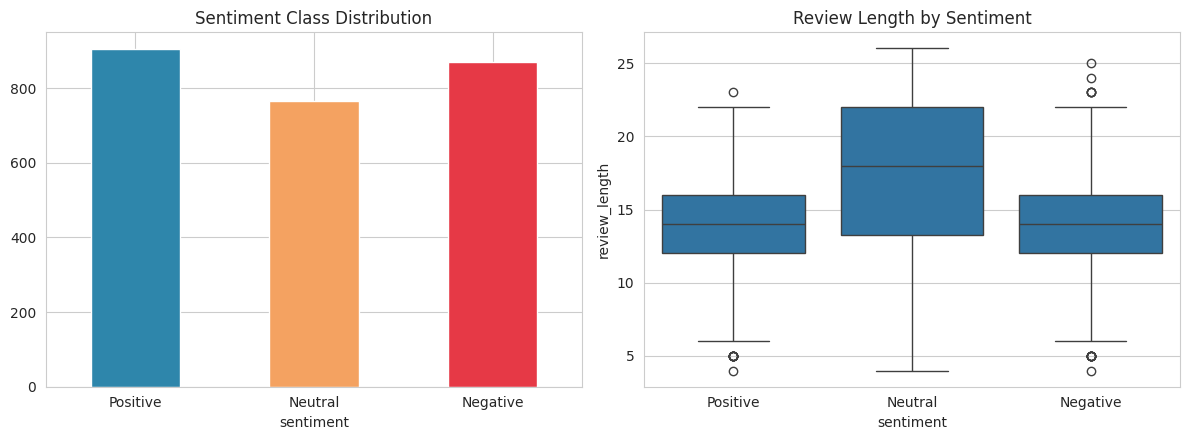

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df["sentiment"].value_counts().reindex(["Positive","Neutral","Negative"]).plot(
    kind="bar", ax=axes[0], color=["#2E86AB","#F4A261","#E63946"])
axes[0].set_title("Sentiment Class Distribution")
axes[0].tick_params(axis="x", rotation=0)
df["review_length"] = df["clean_text"].apply(lambda x: len(x.split()))
sns.boxplot(data=df, x="sentiment", y="review_length", ax=axes[1],
            order=["Positive","Neutral","Negative"])
axes[1].set_title("Review Length by Sentiment")
plt.tight_layout()
plt.show()

## 5. Train/Test Split80/20, stratified so all three sentiment classes stay proportionally represented in both sets.

In [17]:
X = df["clean_text"]
y = df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 2032 | Test size: 509


## 6. TF-IDF VectorizationTF-IDF (Term Frequency – Inverse Document Frequency) weighs each word by how distinctive it is to a specific review, not just how often it appears — common words that show up in almost every review get down-weighted automatically. I include unigrams and bigrams (`ngram_range=(1,2)`) so short phrases like "not bad" or "never worked" are captured, not just single words.

In [19]:
vectorizer = TfidfVectorizer(max_features=2000, stop_words="english", ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("TF-IDF feature count:", X_train_tfidf.shape[1])

TF-IDF feature count: 1756


## 7. Model 1 — Multinomial Naive BayesA classic, fast baseline for text classification — works well with word-frequency-style features like TF-IDF.

In [30]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

## 8. Model 2 — Logistic RegressionUsually performs strongly on high-dimensional sparse text features like TF-IDF, and gives interpretable coefficients per word.

In [31]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_tfidf, y_train)
log_preds = log_model.predict(X_test_tfidf)

## 9. EvaluationI use **macro-averaged** metrics (average performance across all 3 classes equally) rather than accuracy alone, since Neutral is the smallest and hardest class — macro averaging makes sure it isn't masked by strong performance on the larger Positive/Negative classes.

In [32]:
def evaluate(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision (macro):", round(precision_score(y_true, y_pred, average="macro"), 3))
    print("Recall (macro)   :", round(recall_score(y_true, y_pred, average="macro"), 3))
    print("F1 (macro)       :", round(f1_score(y_true, y_pred, average="macro"), 3))
    print()

evaluate("Multinomial Naive Bayes", y_test, nb_preds)
evaluate("Logistic Regression", y_test, log_preds)

--- Multinomial Naive Bayes ---
Accuracy : 0.949
Precision (macro): 0.949
Recall (macro)   : 0.947
F1 (macro)       : 0.948

--- Logistic Regression ---
Accuracy : 0.955
Precision (macro): 0.954
Recall (macro)   : 0.953
F1 (macro)       : 0.954



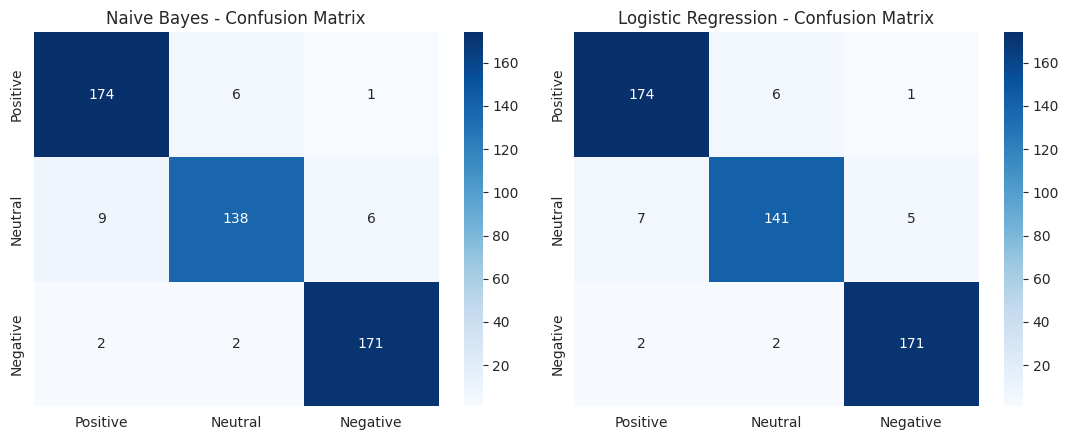

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["Positive", "Neutral", "Negative"]
for ax, (name, preds) in zip(axes, [("Naive Bayes", nb_preds), ("Logistic Regression", log_preds)]):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f"{name} - Confusion Matrix")
plt.tight_layout()
plt.show()

**Result:** Logistic Regression edges out Naive Bayes (95.5% vs 94.9% accuracy). Most errors happen around the **Neutral** class — expected, since neutral/mixed-sentiment reviews are genuinely the hardest for humans to agree on too, not just models.

## 10. Which words drive each sentiment class?

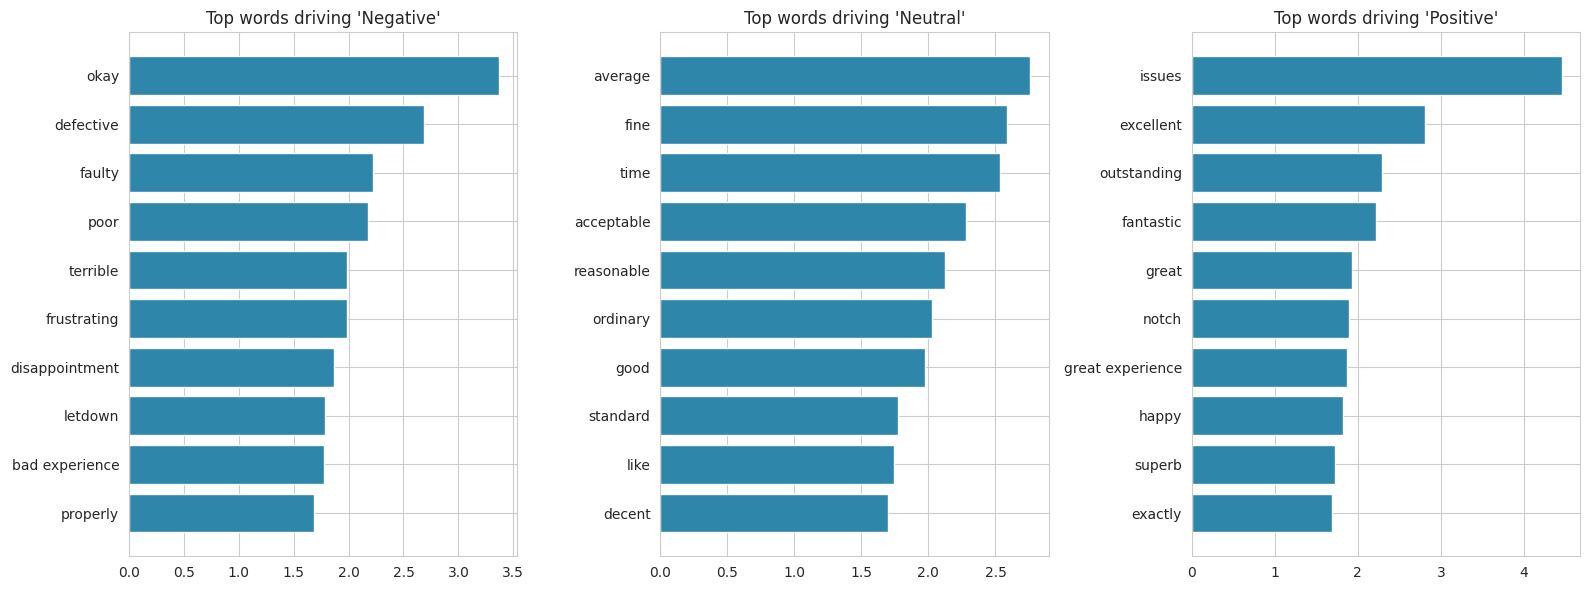

In [34]:
feature_names = np.array(vectorizer.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for idx, cls in enumerate(log_model.classes_):
    coefs = log_model.coef_[idx]
    top_idx = np.argsort(coefs)[-10:]
    axes[idx].barh(feature_names[top_idx], coefs[top_idx], color="#2E86AB")
    axes[idx].set_title(f"Top words driving '{cls}'")
plt.tight_layout()
plt.show()

## 11. Business Recommendations- Automating sentiment tagging lets support/product teams **triage negative feedback first** instead of reading reviews in arrival order — faster response to unhappy customers.- Tracking sentiment **trend over time** (e.g., weekly % negative) can flag emerging product or service issues early, before they show up in churn or NPS surveys.- The **Neutral** class carries the most nuance — in practice, routing Neutral-flagged feedback to a human reviewer (instead of fully automating it) balances automation speed with accuracy.## Tech Stack`Python` · `Pandas` · `NumPy` · `Scikit-learn` (TF-IDF, Naive Bayes, Logistic Regression) · `Matplotlib` · `Seaborn`## What I'd do with more time- Try a transformer-based model (e.g., DistilBERT) and compare against this classical baseline- Build a simple dashboard showing sentiment trend over time- Expand to aspect-based sentiment (e.g., separately scoring "delivery" vs "product quality" within one review)